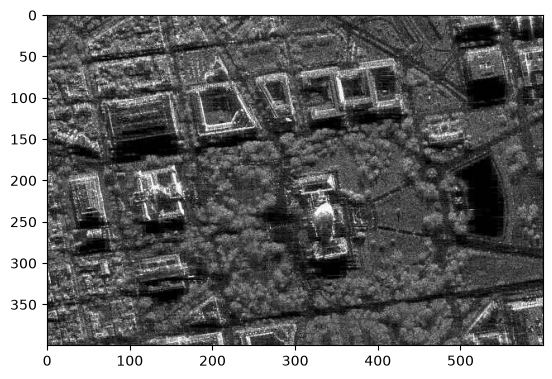

In [3]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

image = cv2.imread('sar_1_gray.jpg', cv2.IMREAD_GRAYSCALE)
plt.imshow(image, 'gray')


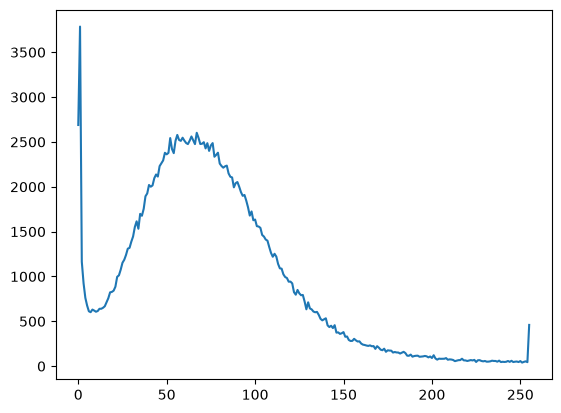

In [4]:
hist = cv2.calcHist([image], [0], None, [256], [0,256])
plt.plot(hist)

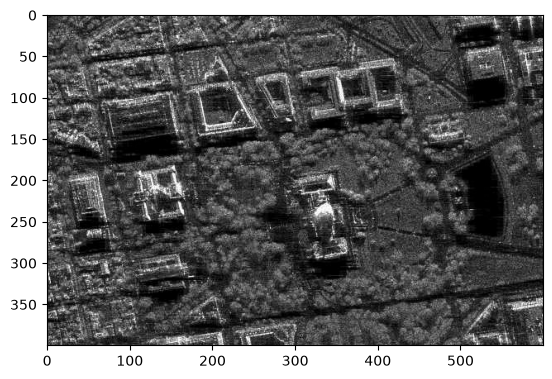

In [5]:
def gamma_correction(img, gamma):
    img_norm = img.astype(np.float32) / 255.0
    result = np.power(img_norm, gamma) * 255.0
    return np.clip(result, 0, 255).astype(np.uint8)
image_dark  = gamma_correction(image, 1.1)
plt.imshow(image_dark, 'gray')

In [6]:
from skimage.metrics import structural_similarity, mean_squared_error
ssim = structural_similarity(image, image_dark)
mse = mean_squared_error(image, image_dark)
print(ssim)
print(mse)

0.9869210487665901
64.54242916666666


74.94157083333333 43.658465466227916


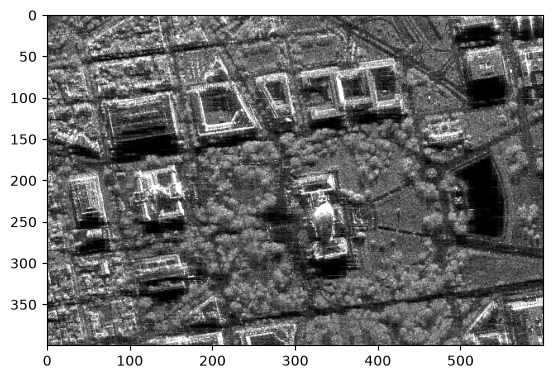

In [21]:
mean = image.mean()
std = image.std()
target_mean = eq_gray.mean()
target_std = eq_gray.std()
print(mean,std)
corrected = (image.astype(np.float32) - mean) * (target_std / mean) + target_mean
corrected = np.clip(corrected, 0, 255).astype(np.uint8)
plt.imshow(corrected, 'gray')

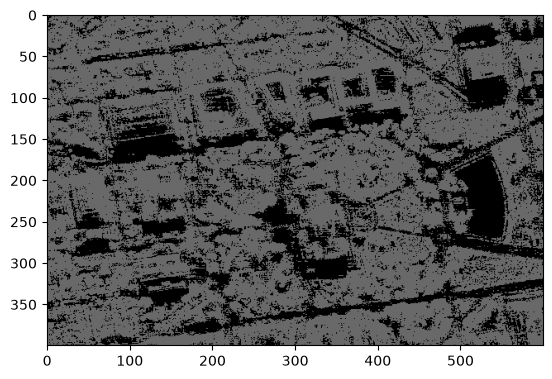

In [16]:
_, thresh1 = cv2.threshold(image, 50, 105, cv2.THRESH_BINARY)
plt.imshow(thresh1, 'gray', vmin=0, vmax=255)